# Consumer Shopping Preference Analysis
### A Python Data Product on the Drivers of Store, Online, and Hybrid Shopping Preference

This project investigates what drives consumer shopping preference across three modes: **Store**, **Online**, and **Hybrid**.  
Using a consumer shopping behavior dataset, the analysis focuses on whether demographic, digital, psychological, and behavioral factors help explain these preferences.

The notebook is designed as the main analytical showcase of the project. It follows a coherent workflow from **data loading** and **preprocessing** to **main analysis**, **behavioral evidence**, and **lightweight machine learning validation**.

## Notebook Roadmap

This notebook follows the workflow below:

1. Load the raw dataset  
2. Preprocess and prepare the data  
3. Analyze the main drivers of shopping preference  
4. Add behavioral evidence  
5. Use a lightweight ML model for validation  
6. Summarize the final insights

In [15]:
import pandas as pd

from src.data_loader import get_raw_data, save_processed_data
from src.preprocess import preprocess_pipeline, get_data_summary
from src.analysis_main import (
    get_variable_groups,
    analyze_preference_overview,
    analyze_demographic_drivers,
    analyze_digital_drivers,
    analyze_psychological_drivers,
)
from src.analysis_behavior import run_behavior_analysis
from src.model import run_ml_analysis, build_ml_insight_summary, plot_ml_top_features

In [16]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Data Loading

The raw dataset is loaded from the project's `data/raw/` folder.  
This section first inspects the dataset structure before any preprocessing is applied.

In [17]:
raw_df = get_raw_data()
raw_df.shape

(11789, 25)

In [18]:
raw_df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,discount_sensitivity,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,144092,2,3,2,6,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,28421,4,7,4,1,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,128229,9,4,5,3,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,134650,7,0,3,3,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,34122,5,9,2,4,2,5,8,9,7,1,6,Male,Tier 3,Store


In [19]:
list(raw_df.columns)

['age',
 'monthly_income',
 'daily_internet_hours',
 'smartphone_usage_years',
 'social_media_hours',
 'online_payment_trust_score',
 'tech_savvy_score',
 'monthly_online_orders',
 'monthly_store_visits',
 'avg_online_spend',
 'avg_store_spend',
 'discount_sensitivity',
 'return_frequency',
 'avg_delivery_days',
 'delivery_fee_sensitivity',
 'free_return_importance',
 'product_availability_online',
 'impulse_buying_score',
 'need_touch_feel_score',
 'brand_loyalty_score',
 'environmental_awareness',
 'time_pressure_level',
 'gender',
 'city_tier',
 'shopping_preference']

The raw dataset includes variables related to:

- demographic background,
- digital capability,
- shopping behavior,
- psychological tendencies,
- and the final target variable: **shopping preference**.

Before analysis, the data need to be cleaned, standardized, and extended with a small number of transparent derived features.

## 2. Data Preprocessing

The preprocessing pipeline performs the following steps:

- standardizes column names,
- converts key variables into appropriate data types,
- handles missing values,
- clips extreme outliers,
- and creates lightweight derived features for later analysis.

These steps are designed to make the dataset stable, reusable, and ready for downstream modules.

In [20]:
clean_df = preprocess_pipeline(raw_df)
clean_df.shape

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\preprocess.py:105: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["online_activity_share"] = df["online_activity_share"].fillna(0)
g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\preprocess.py:106: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["store_activity_share"] = df["store_activity_share"].fillna(0)


(11789, 29)

In [21]:
data_summary = get_data_summary(clean_df)
data_summary

{'shape': (11789, 29),
 'total_missing_values': 0,
 'numeric_columns': ['age',
  'monthly_income',
  'daily_internet_hours',
  'smartphone_usage_years',
  'social_media_hours',
  'online_payment_trust_score',
  'tech_savvy_score',
  'monthly_online_orders',
  'monthly_store_visits',
  'avg_online_spend',
  'avg_store_spend',
  'discount_sensitivity',
  'return_frequency',
  'avg_delivery_days',
  'delivery_fee_sensitivity',
  'free_return_importance',
  'product_availability_online',
  'impulse_buying_score',
  'need_touch_feel_score',
  'brand_loyalty_score',
  'environmental_awareness',
  'time_pressure_level',
  'total_shopping_activity',
  'online_activity_share',
  'store_activity_share'],
 'categorical_columns': ['gender',
  'city_tier',
  'shopping_preference',
  'income_group']}

In [22]:
clean_df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,discount_sensitivity,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference,total_shopping_activity,online_activity_share,store_activity_share,income_group
0,56,221111.0,6.5,12,0.7,1,6,16,16,28551.0,144092.0,2,3,2,6,7,7,1,3,6,5,2,Other,Tier 3,Store,32,0.500000,0.500000,High
1,69,96029.0,8.2,13,2.7,6,9,14,1,124056.0,28421.0,4,7,4,1,3,4,9,6,8,1,7,Male,Tier 3,Hybrid,15,0.933333,0.066667,Lower-Middle
2,46,19055.0,6.4,4,2.1,10,8,2,0,81939.0,128229.0,9,4,5,3,4,10,1,1,3,3,3,Female,Tier 3,Store,2,1.000000,0.000000,Low
3,32,53170.0,6.4,11,0.7,2,10,20,3,35901.0,134650.0,7,0,3,3,10,2,4,8,2,6,6,Female,Tier 1,Store,23,0.869565,0.130435,Low
4,60,244016.0,6.0,5,0.7,2,5,18,16,131971.0,34122.0,5,9,2,4,2,5,8,9,7,1,6,Male,Tier 3,Store,34,0.529412,0.470588,High


In [23]:
processed_path = save_processed_data(clean_df)
processed_path

WindowsPath('G:/NefelibataEpi/2026/ACC102 - MiniCoursework/code/data/processed/consumer_shopping_trends_processed.csv')

The processed dataset is now ready for analysis.

In addition to cleaning and standardization, preprocessing also created several helpful derived features, including:

- `total_shopping_activity`
- `online_activity_share`
- `store_activity_share`
- `income_group`

These features will support later behavioral and explanatory analysis.

## 3. Main Analysis: What Drives Shopping Preference?

This is the core analytical section of the project.

The main goal is to examine which factors best explain differences in consumer shopping preference across **Store**, **Online**, and **Hybrid** groups.

In [24]:
groups = get_variable_groups(clean_df)
groups

{'target': ['shopping_preference'],
 'demographic': ['age',
  'monthly_income',
  'income_group',
  'gender',
  'city_tier'],
 'digital': ['daily_internet_hours',
  'smartphone_usage_years',
  'social_media_hours',
  'online_payment_trust_score',
  'tech_savvy_score'],
 'psychological': ['discount_sensitivity',
  'delivery_fee_sensitivity',
  'free_return_importance',
  'product_availability_online',
  'impulse_buying_score',
  'need_touch_feel_score',
  'brand_loyalty_score',
  'environmental_awareness',
  'time_pressure_level'],
 'behavior': ['monthly_online_orders',
  'monthly_store_visits',
  'avg_online_spend',
  'avg_store_spend',
  'return_frequency',
  'avg_delivery_days',
  'total_shopping_activity',
  'online_activity_share',
  'store_activity_share']}

The main analysis is organized into three explanatory groups:

- **Demographic factors**
- **Digital capability factors**
- **Psychological factors**

The target variable throughout this section is **shopping preference**.

### 3.1 Preference Overview

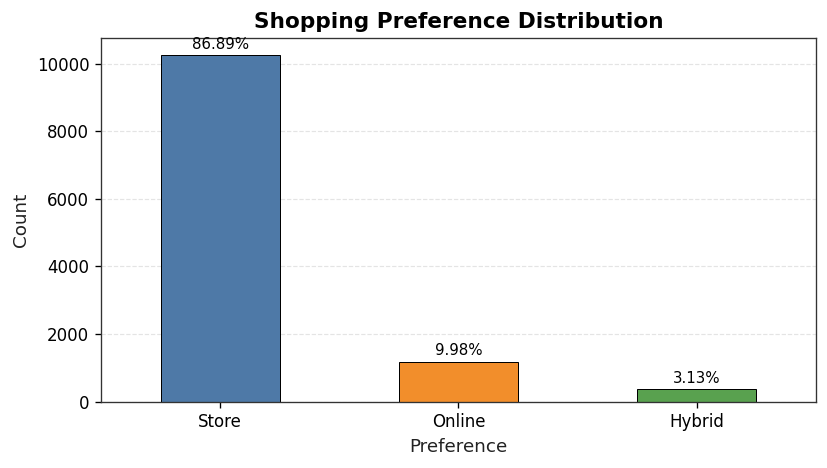

,count,percentage
shopping_preference,,
Store,10244,86.89
Online,1176,9.98
Hybrid,369,3.13


In [25]:
overview_result = analyze_preference_overview(
    clean_df,
    plot=True,
    save_fig=True
)

overview_result["summary_table"]

The distribution of shopping preference is clearly imbalanced.

**Store** is the dominant preference group in the dataset, while **Online** is much smaller and **Hybrid** is the smallest segment.  
This means the key analytical task is not to treat Hybrid as a mainstream pattern, but to understand what differentiates the smaller Online and Hybrid groups from the dominant Store group.

### 3.2 Demographic Drivers

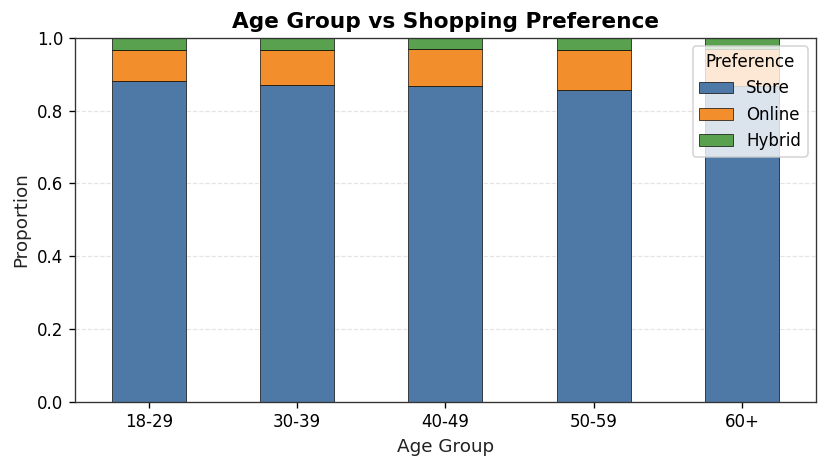

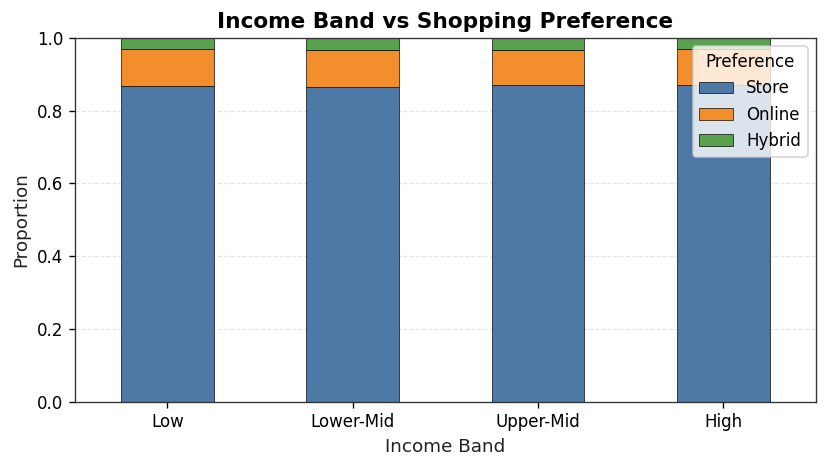

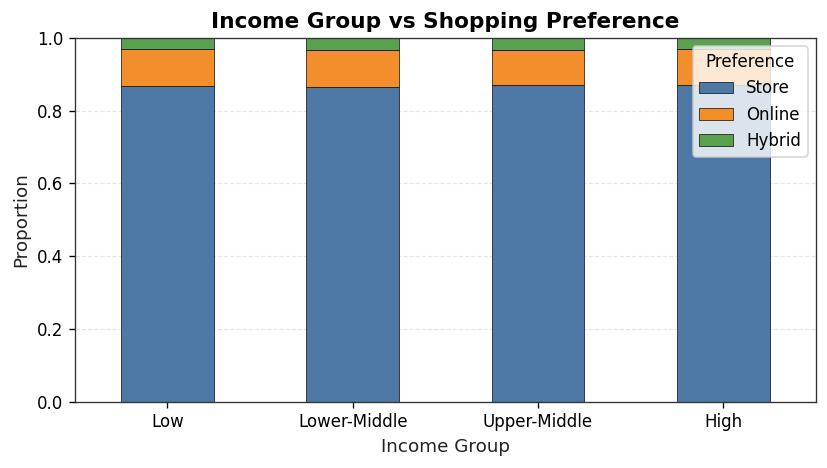

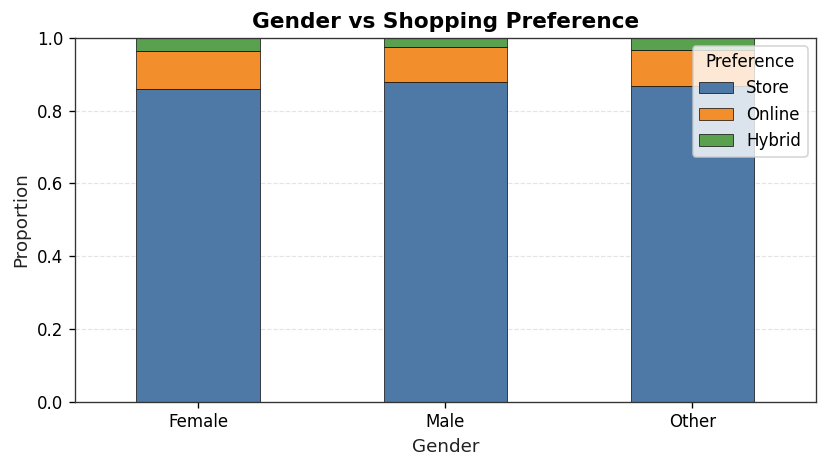

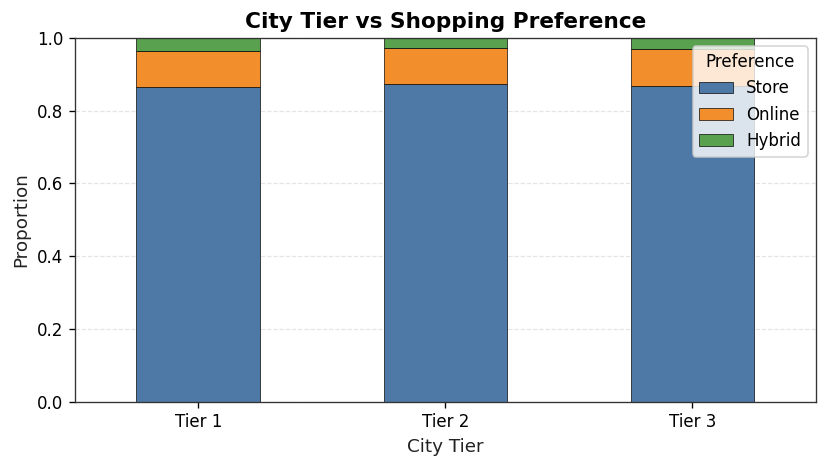

gender            0.131333
age               0.131200
monthly_income    0.131000
income_group      0.131000
city_tier         0.131000
Name: deviation_from_store, dtype: float64

In [26]:
demographic_result = analyze_demographic_drivers(
    clean_df,
    demographic_cols=groups["demographic"],
    plot=True,
    save_fig=True
)

demographic_result["driver_summary"]

Demographic variables provide only limited explanatory power in this dataset.

Although age, income, gender, and city tier are useful for basic segmentation, the preference structure remains broadly similar across most demographic groups.  
This suggests that demographic background alone is not enough to explain why most consumers still prefer Store over Online or Hybrid shopping.

### 3.3 Digital Drivers

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:278: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


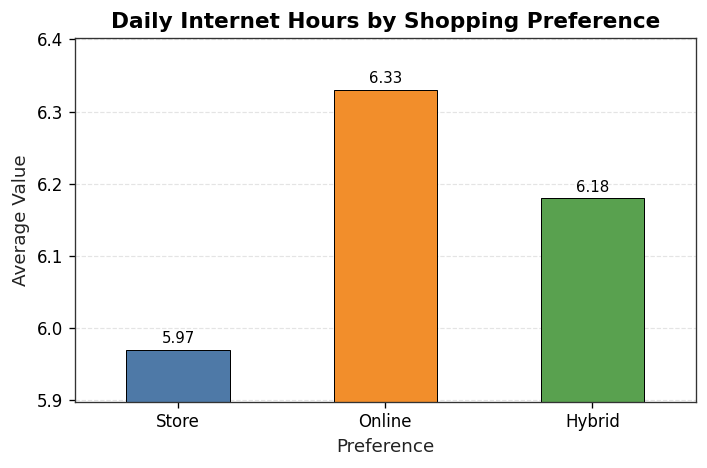

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:278: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


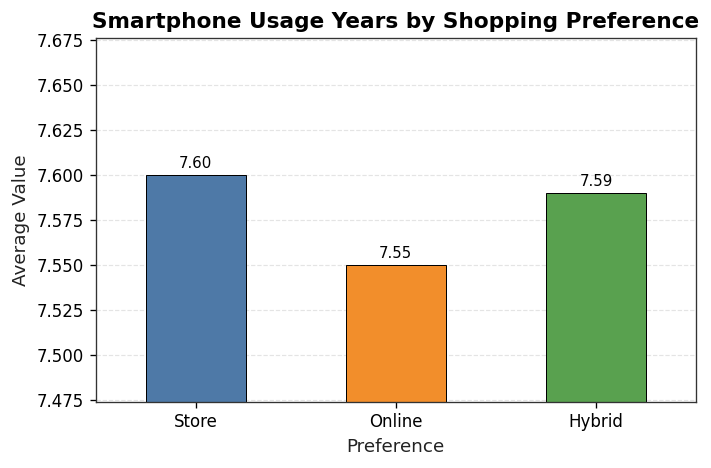

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:278: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


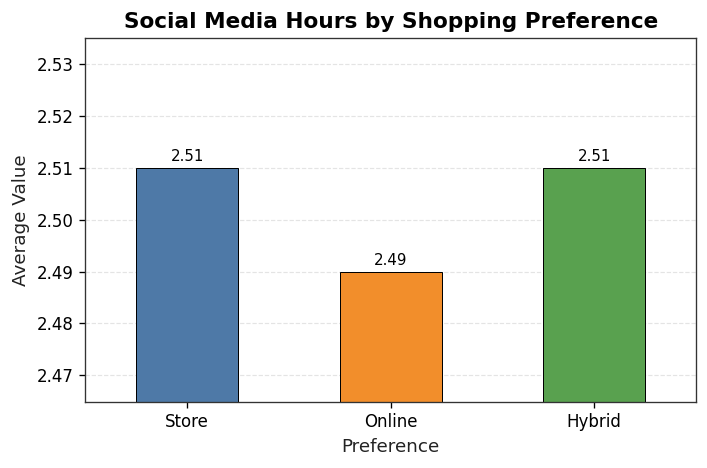

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:278: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


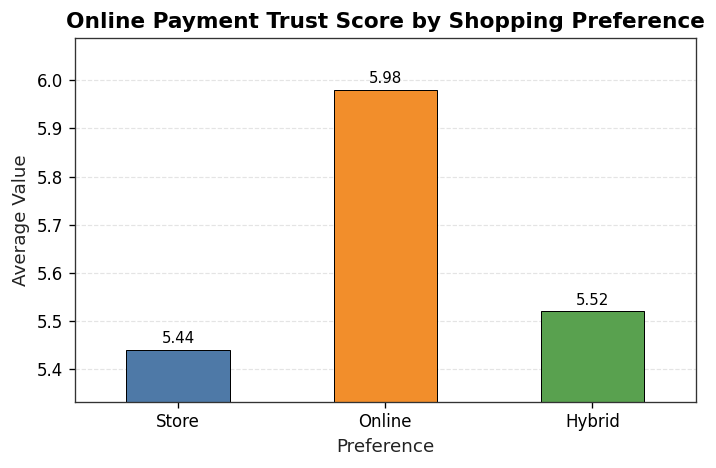

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:278: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


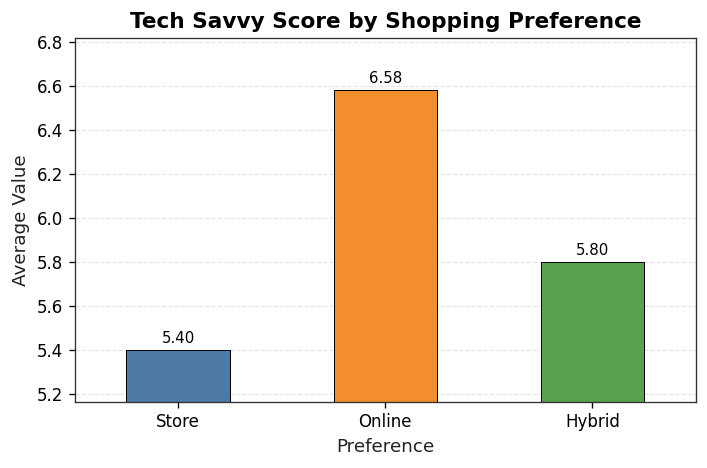

tech_savvy_score              1.18
online_payment_trust_score    0.54
daily_internet_hours          0.36
smartphone_usage_years        0.05
social_media_hours            0.02
Name: driver_strength, dtype: float64

In [27]:
digital_result = analyze_digital_drivers(
    clean_df,
    digital_cols=groups["digital"],
    plot=True,
    save_fig=True
)

digital_result["driver_summary"]

Digital capability shows some relationship with shopping preference, but the overall effect remains modest.

Variables such as **tech-savviness** and **online payment trust** appear more relevant than simple exposure measures such as years of smartphone use.  
Overall, digital capability seems to provide an enabling effect, but it does not fully explain shopping preference by itself.

### 3.4 Psychological Drivers

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


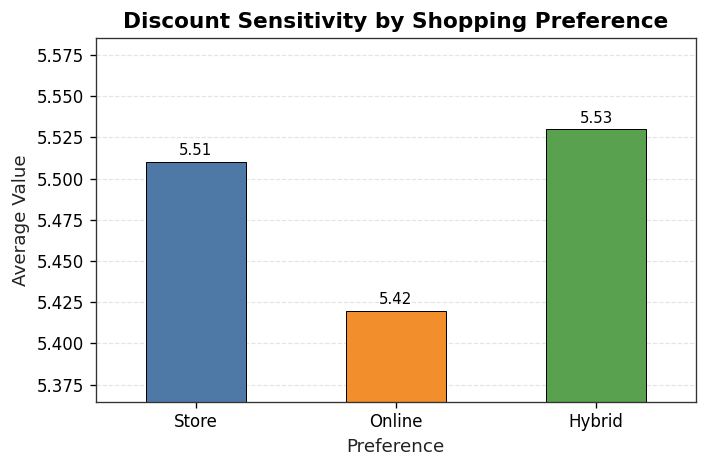

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


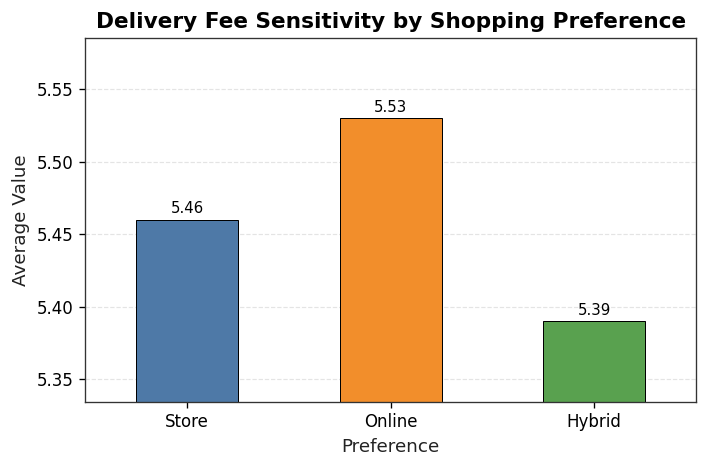

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


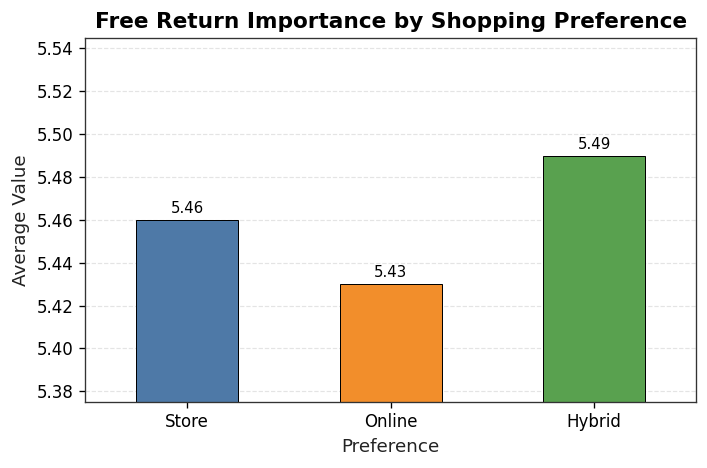

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


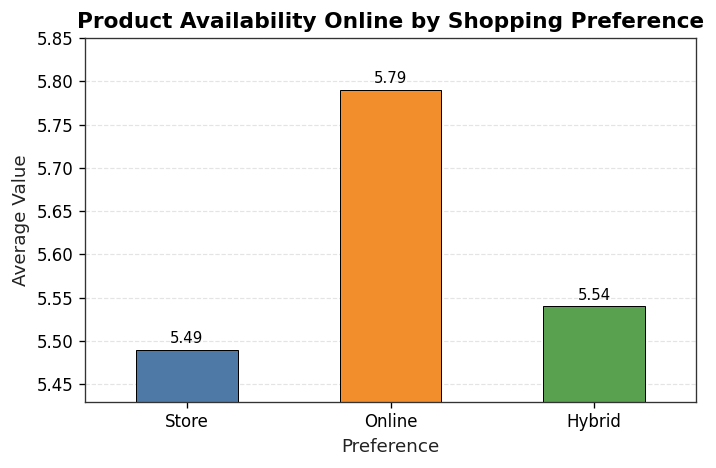

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


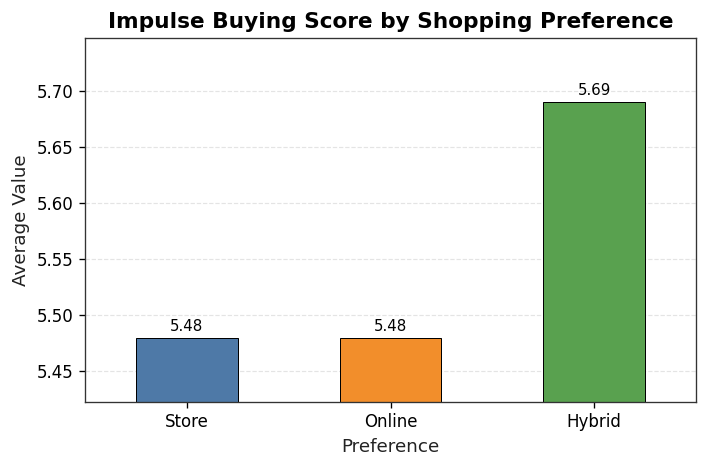

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


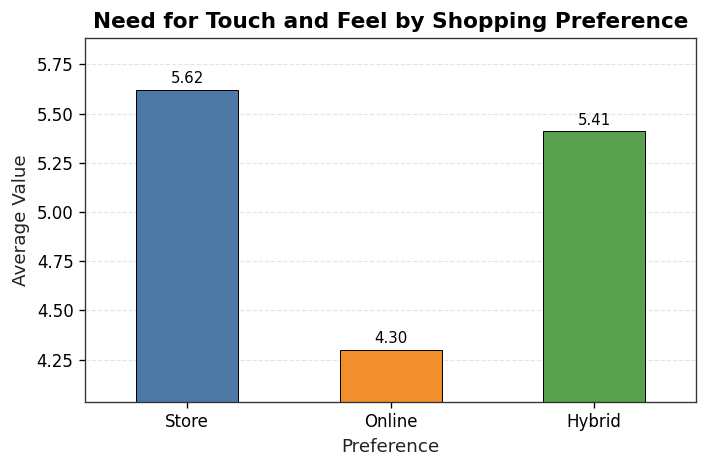

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


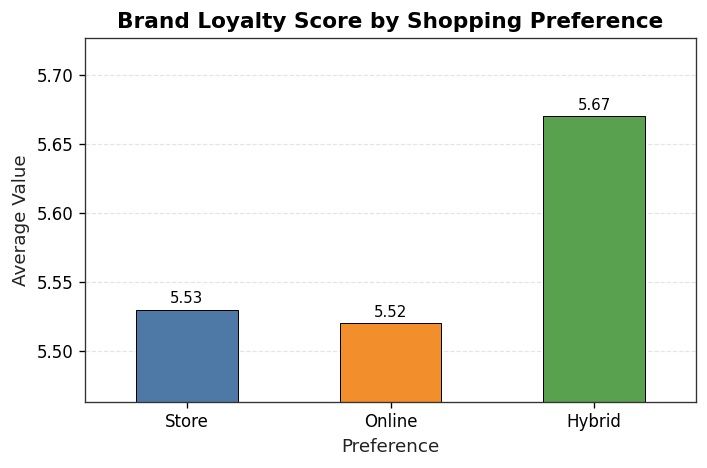

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


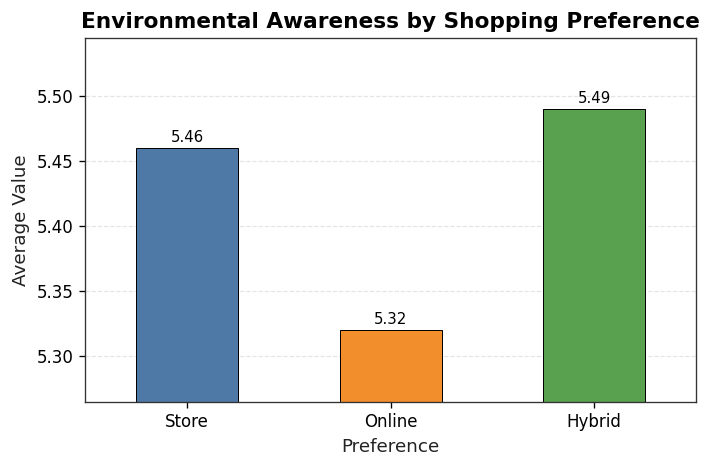

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_main.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[col]


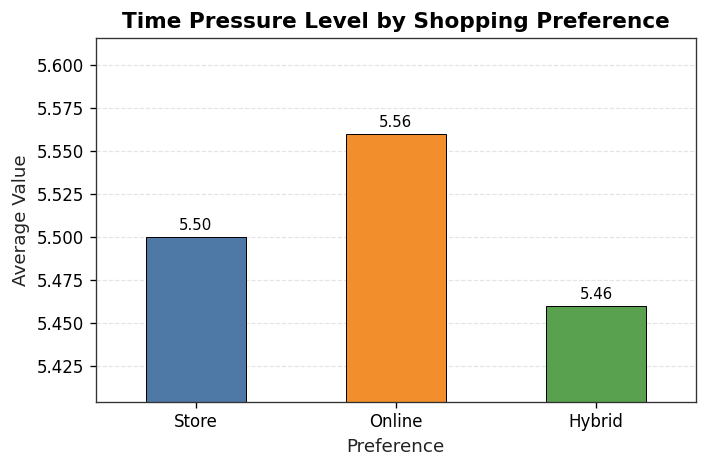

need_touch_feel_score          1.32
product_availability_online    0.30
impulse_buying_score           0.21
environmental_awareness        0.17
brand_loyalty_score            0.15
delivery_fee_sensitivity       0.14
discount_sensitivity           0.11
time_pressure_level            0.10
free_return_importance         0.06
Name: driver_strength, dtype: float64

In [28]:
psych_result = analyze_psychological_drivers(
    clean_df,
    psych_cols=groups["psychological"],
    plot=True,
    save_fig=True
)

psych_result["driver_summary"]

Psychological variables provide the strongest explanatory evidence among the tested groups.

In particular, factors related to the shopping experience — especially the desire to physically inspect or interact with products — appear more powerful than simple demographic identity or digital readiness.  
This suggests that shopping preference is shaped less by who consumers are, and more by how they evaluate the shopping experience itself.

### 3.5 Interim Conclusion from the Main Analysis

The main analysis suggests the following pattern:

- **Demographic factors** are relatively weak drivers.
- **Digital capability** contributes modestly.
- **Psychological factors** provide the strongest explanation.

This means the dominant Store preference in the dataset is best understood not as a purely demographic outcome, but as a result of how consumers perceive convenience, trust, and the need for physical product interaction.

## 4. Behavior Analysis: Does Preference Match Actual Behavior?

This section provides behavioral evidence to support the main analysis.

While the earlier section focused on **why** shopping preference may differ, this section focuses on **how consumers actually behave** across Store, Online, and Hybrid groups.

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_behavior.py:344: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)
g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_behavior.py:350: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(target_col).size().rename(("group_info", "count"))
g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_behavior.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

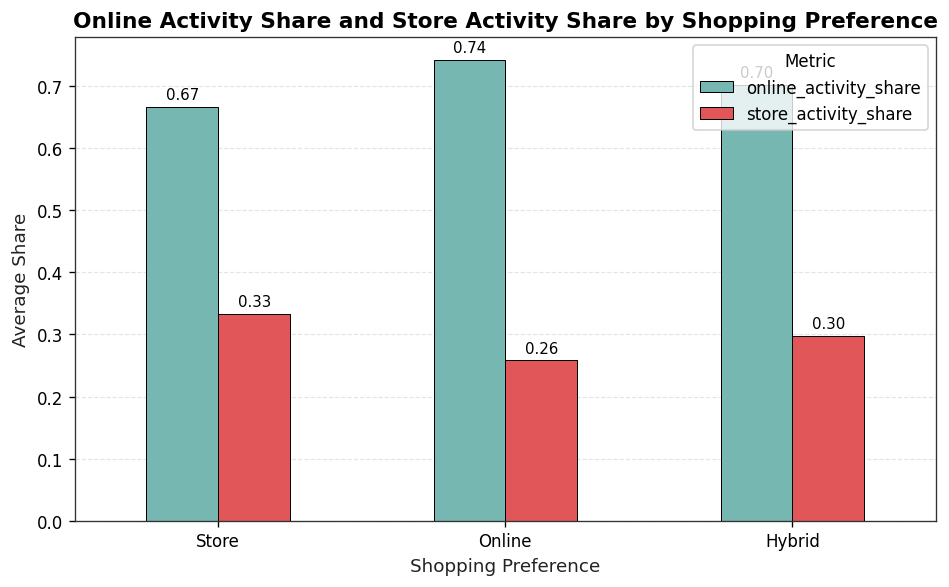

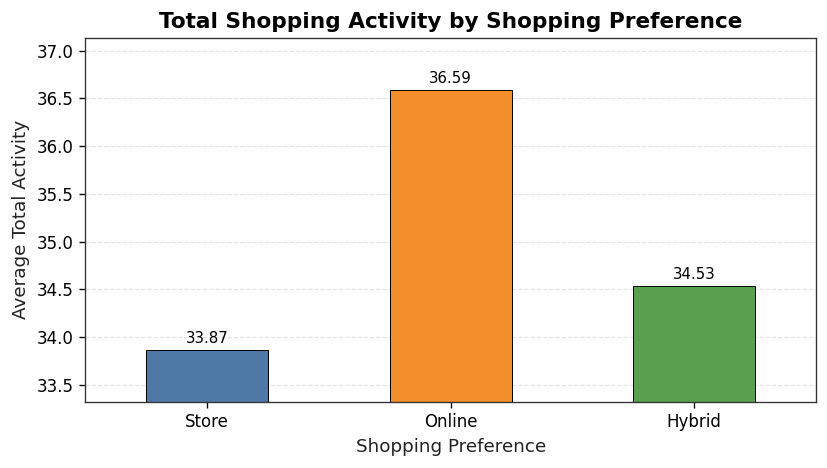

g:\NefelibataEpi\2026\ACC102 - MiniCoursework\code\src\analysis_behavior.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(target_col)[behavior_cols]


In [29]:
behavior_result = run_behavior_analysis(
    clean_df,
    plot=True,
    round_digits=3,
    save_fig=True
)

In [30]:
behavior_result["overall_summary"]

group_info monthly_online_orders        monthly_store_visits        avg_online_spend           \
                         count                  mean median                 mean median             mean   median   
shopping_preference                                                                                                 
Store                    10244                24.235   24.0                9.632   10.0        74346.981  74603.0   
Online                    1176                28.310   30.0                8.280    8.0        76426.135  77761.5   
Hybrid                     369                25.385   26.0                9.149    9.0        74301.293  72540.0   

                    avg_store_spend          return_frequency        avg_delivery_days        total_shopping_activity  \
                               mean   median             mean median              mean median                    mean   
shopping_preference                                                                                                     
Store                     85095.070  85313.0            4.478    4.0             3.995    4.0                  33.867   
Online                    11244.757   9413.5            4.381    4.0             4.063    4.0                  36.589   
Hybrid                    19041.816  18899.0            4.455    4.0             3.927    4.0                  34.534   

                           online_activity_share        store_activity_share        time_pressure_level         
                    median                  mean median                 mean median                mean median  
shopping_preference                                                                                             
Store                 34.0                 0.666  0.714                0.333  0.286               5.499    6.0  
Online                38.0                 0.742  0.778                0.258  0.222               5.560    6.0  
Hybrid                35.0                 0.702  0.735                0.298  0.265               5.458    5.0

In [31]:
behavior_result["activity_structure"]["summary_table"]

total_shopping_activity        online_activity_share        store_activity_share       
                                       mean median                  mean median                 mean median
shopping_preference                                                                                        
Store                                33.867   34.0                 0.666  0.714                0.333  0.286
Online                               36.589   38.0                 0.742  0.778                0.258  0.222
Hybrid                               34.534   35.0                 0.702  0.735                0.298  0.265

In [32]:
behavior_result["hybrid_position"]

,variable,store_mean,hybrid_mean,online_mean,dist_to_store,dist_to_online,position,closer_to
0,monthly_online_orders,24.235,25.385,28.310,1.150,2.925,in-between,Store
1,monthly_store_visits,9.632,9.149,8.280,0.483,0.869,in-between,Store
2,avg_online_spend,74346.981,74301.293,76426.135,45.688,2124.842,outside-range,Store
3,avg_store_spend,85095.070,19041.816,11244.757,66053.254,7797.059,in-between,Online
4,return_frequency,4.478,4.455,4.381,0.023,0.074,in-between,Store
5,avg_delivery_days,3.995,3.927,4.063,0.068,0.136,outside-range,Store
6,total_shopping_activity,33.867,34.534,36.589,0.667,2.055,in-between,Store
7,online_activity_share,0.666,0.702,0.742,0.036,0.040,in-between,Store
8,store_activity_share,0.333,0.298,0.258,0.035,0.040,in-between,Store


The behavioral evidence broadly supports the earlier findings.

In particular:

- shopping preference is reflected in how consumers allocate activity between online and store channels,
- activity-share variables provide the clearest behavioral support,
- and Hybrid consumers appear to occupy an intermediate position.

At the same time, the behavioral differences are generally modest rather than dramatic.  
This suggests that shopping preference is not explained by behavior alone, but behavior still provides useful supporting evidence for the main story.

## 5. ML Validation: A Lightweight Consistency Check

This section uses a simple and interpretable machine learning model as a lightweight validation layer.

The purpose is **not** to maximize predictive performance.  
Instead, the goal is to check whether the earlier analytical pattern is broadly supported when the same problem is viewed through a simple classification model.

In [33]:
ml_output = run_ml_analysis(clean_df)
ml_output["summary_table"]

,feature_set,model,train_size,test_size,accuracy,top_feature
0,full_core,Multinomial Logistic Regression,9431,2358,0.4508,need_touch_feel_score
1,demo_digital,Multinomial Logistic Regression,9431,2358,0.4449,tech_savvy_score
2,demographic_only,Multinomial Logistic Regression,9431,2358,0.2943,income_group_High


In [34]:
ml_insight = build_ml_insight_summary(ml_output)
ml_insight["summary_table"]

,feature_set,model,train_size,test_size,accuracy,top_feature
0,full_core,Multinomial Logistic Regression,9431,2358,0.4508,need_touch_feel_score
1,demo_digital,Multinomial Logistic Regression,9431,2358,0.4449,tech_savvy_score
2,demographic_only,Multinomial Logistic Regression,9431,2358,0.2943,income_group_High


In [35]:
ml_insight["top_features"]

,rank,feature,importance,feature_group
0,1,need_touch_feel_score,0.209116,psychological
1,2,tech_savvy_score,0.174587,digital
2,3,income_group_High,0.101024,demographic
3,4,online_payment_trust_score,0.094046,digital
4,5,gender_Female,0.089354,demographic
5,6,daily_internet_hours,0.087022,digital
6,7,gender_Male,0.064901,demographic
7,8,monthly_income,0.062612,demographic
8,9,product_availability_online,0.059450,psychological
9,10,city_tier_Tier 2,0.049340,demographic


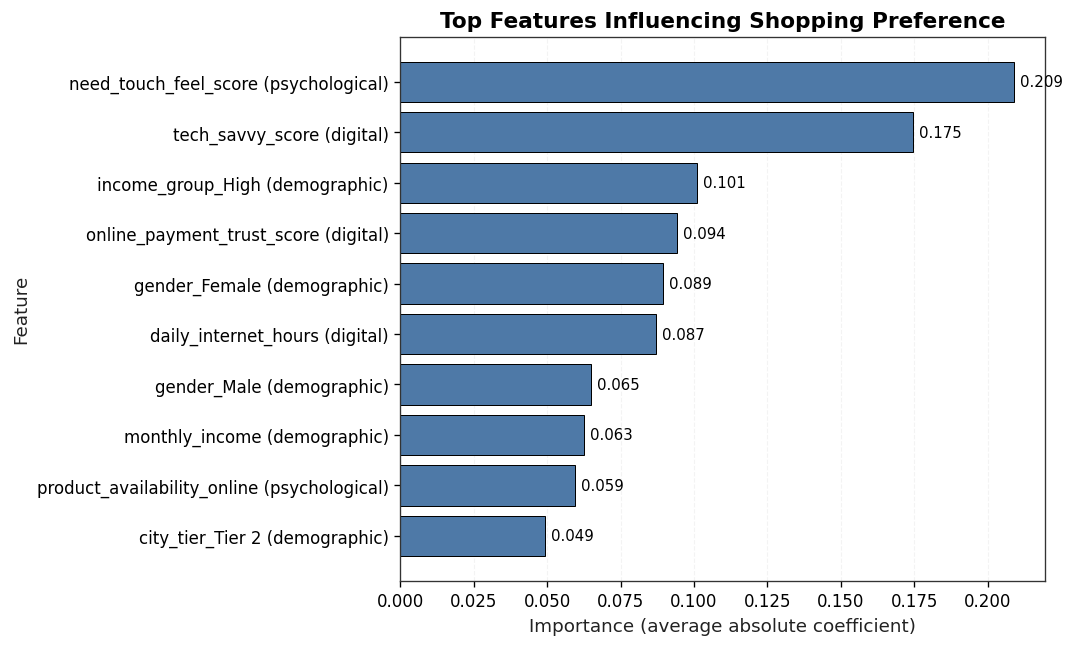

In [36]:
fig, ax = plot_ml_top_features(
    ml_output,
    feature_set_name="full_core",
    top_n=10,
    save_fig=True
)

The ML results are consistent with the earlier analytical interpretation.

A simple staged comparison shows that:

- demographic-only features provide relatively weak predictive performance,
- adding digital variables improves the model,
- and the full feature set performs best.

Most importantly, the top features from the interpretable model are consistent with the earlier conclusion that psychological and experience-related factors matter more than basic demographic identity alone.

This means the ML module supports the project as a **validation layer**, rather than replacing the earlier explanatory analysis.

## 6. Final Integrated Insights

The full project leads to the following main conclusions:

1. **Store is the dominant shopping preference** in the dataset, while Online is smaller and Hybrid is a minor segment.  
2. **Demographic variables have limited explanatory power**, meaning they are not the main reason why consumers differ in shopping preference.  
3. **Digital capability contributes modestly**, especially through variables related to trust and tech readiness, but it does not dominate the explanation.  
4. **Psychological factors provide the strongest explanation**, especially factors linked to how consumers experience the shopping process.  
5. **Behavioral evidence broadly matches stated preference**, showing that preference is reflected in actual shopping activity structure.  
6. **A simple interpretable ML model supports the same overall pattern**, confirming that the project’s main conclusions remain stable across analytical approaches.

## 7. Limitations and Possible Improvements

This project still has several limitations.

First, the dataset shows an imbalanced preference distribution, especially with a relatively small Hybrid group.  
Second, many differences across groups are modest rather than large, so results should be interpreted carefully.  
Third, the ML component was intentionally kept simple in order to prioritize interpretability over performance.

Possible future improvements could include richer segmentation, more targeted visual comparisons, or a more interactive product layer built on top of the current analytical workflow.

## 8. Closing Note

Overall, this project shows that shopping preference is shaped less by basic demographic identity and more by how consumers perceive and experience the shopping process.

The notebook therefore presents a complete Python-based workflow from data preparation to insight generation, behavioral evidence, and lightweight validation.